### Exercício 1

Considere, no espaço $\mathbb{R}^2$, as normas euclidiana $||.||_2$, da soma $||.||_1$ e do máximo $||.||_\infty$. Determine, geometricamente, para cada uma dessas normas, o conjunto $B=\{x\in \mathbb{R}^2 / ||x||=1\}$.




### **Exemplos de normas do $\mathbb{R}^n$**

- $$ \|\mathbf{x}\|_2 = \bigg( \sum_{i=1}^n |x_i|^2 \bigg)^{1/2}, \qquad $$
- $$ \|\mathbf{x}\|_\infty = \max \limits _{1 \leq i \leq n} | x_{i} |, \qquad $$
- $$ \|\mathbf{x}\|_1 = \sum _{i=1} ^n | x_{i} | $$

- $$ \|\mathbf{x}\|_p = \bigg( \sum_{i=1}^n |x_i|^p \bigg)^{1/p}, \; p \geq 1 $$

- Esfera com centro na origem e raio unitário.
$$ S = \{\mathbf{x} \in \mathbb{R}^n; \; \|\mathbf{x}\|=1\} $$


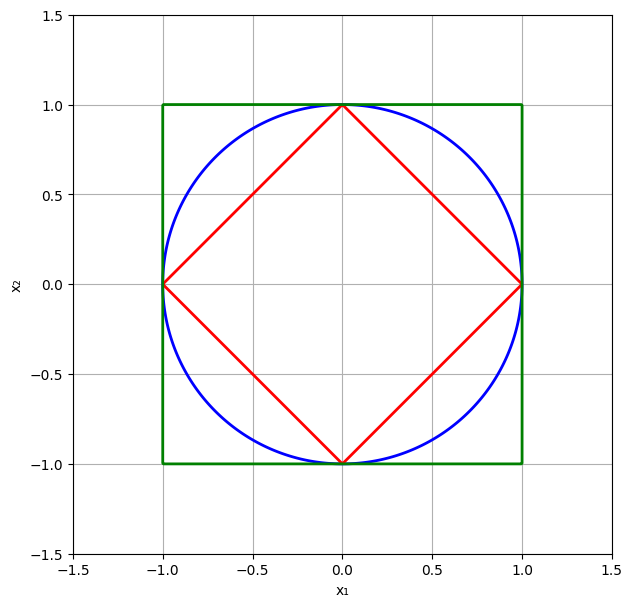

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Criando um grid
x = np.linspace(-1.5, 1.5, 400)
y = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x, y)

# Norma da Soma (1)
norm1 = np.abs(X) + np.abs(Y)

# Norma Euclidiana (2)
norm2 = np.sqrt(X**2 + Y**2)

# Norma do Máximo (inf.)
norm_inf = np.maximum(np.abs(X), np.abs(Y))

# Plotando as figuras (curvas de nível quando o resultado é 1, z=1)
plt.figure(figsize=(7,7))
plt.contour(X, Y, norm1, levels=[1], colors='red', linewidths=2)        # vermelho = norma da soma
plt.contour(X, Y, norm2, levels=[1], colors='blue', linewidths=2)       # azul = norma euclidiana
plt.contour(X, Y, norm_inf, levels=[1], colors='green', linewidths=2)   # verde = norma do máximo

# Configurações do gráfico
plt.gca().set_aspect('equal')
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.grid(True)
plt.show()

### Exercício 2
Considere uma base $B =  \{\mathbf{v}_1,\ldots,\mathbf{v}_{10}\}$ do $\mathbb{R}^{10}$ gerada pelo código abaixo. Implemente um código do processo de ortogonalização de Gram-Schmidt e obtenha uma base ortonormal do $\mathbb{R}^{10}$ a partir de $B$.

In [ ]:
import numpy as np

# Garantir reprodutibilidade
np.random.seed(42)

# Começar com a matriz identidade
I = np.identity(10, dtype=int)

# Adicionar pequenas perturbações inteiras para evitar vetores ortogonais triviais
perturbation = np.random.randint(-3, 4, size=(10, 10))  # valores entre -3 e 3
B_int = I + perturbation

# Verificar se os vetores são linearmente independentes
rank = np.linalg.matrix_rank(B_int)
if rank == 10:
    # Imprimir vetores
    for i in range(10):
        print(f"v{i+1} = {B_int[:, i]}")
else:
    print("Os vetores não são linearmente independentes. Tente novamente.")

v1 = [ 4  3  2  0  2  1  2  0  0 -2]
v2 = [ 0  0  2 -3  2 -1 -2  3 -2 -2]
v3 = [ 1 -1 -1 -3  3  3 -2  0  2  0]
v4 = [ 3  1  0  0  2  1 -3  1  2 -2]
v5 = [-1  0  1 -1  0 -3 -2  3  2 -2]
v6 = [ 1 -1 -3  3  0  4  1 -1 -2  2]
v7 = [ 1  2  0 -2  3 -2 -1  2  0  0]
v8 = [ 3  1 -2  0  0  0  0 -2  2  2]
v9 = [-2 -2  2  0 -3 -3  0  0  2  3]
v10 = [-1  0  1  3 -1  0  3 -2  3  4]


In [ ]:
import numpy as np

# Função de Gram-Schmidt
def gram_schmidt(V):
    n = V.shape[1]
    Q = np.zeros_like(V, dtype=float)

    for i in range(n):
        # Começa com o vetor original
        u = V[:, i].astype(float)

        # Para cada vetor, remove suas projeções nos vetores anteriores (ortogonaliza)
        for j in range(i):
            proj = np.dot(Q[:, j], V[:, i]) * Q[:, j]
            u -= proj

        # Normaliza o vetor resultante
        Q[:, i] = u / np.linalg.norm(u)

    return Q

# Aplicar o processo
Q = gram_schmidt(B_int)

# Verificar se Q é ortonormal 
print("\nVerificação (QᵀQ = I):")
print(np.round(Q.T @ Q, 3))


Verificação (QᵀQ = I):
[[ 1. -0.  0. -0.  0.  0. -0.  0. -0.  0.]
 [-0.  1.  0. -0.  0.  0.  0. -0. -0. -0.]
 [ 0.  0.  1.  0. -0. -0. -0.  0. -0.  0.]
 [-0. -0.  0.  1. -0. -0.  0. -0. -0.  0.]
 [ 0.  0. -0. -0.  1.  0. -0.  0.  0.  0.]
 [ 0.  0. -0. -0.  0.  1. -0.  0. -0.  0.]
 [-0.  0. -0.  0. -0. -0.  1.  0.  0.  0.]
 [ 0. -0.  0. -0.  0.  0.  0.  1. -0. -0.]
 [-0. -0. -0. -0.  0. -0.  0. -0.  1. -0.]
 [ 0. -0.  0.  0.  0.  0.  0. -0. -0.  1.]]
